# 04 - ML Forecasting

This notebook reads processed ML forecasts, metrics and interpretability outputs. It does not retrain models.

In [1]:
from pathlib import Path
import os
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))
import pandas as pd
import matplotlib.pyplot as plt
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
REPORTS = PROJECT_ROOT / 'reports'
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
ml_pred = pd.read_parquet(PROCESSED / 'ml_predictions_store_department.parquet')
baseline = pd.read_parquet(PROCESSED / 'baseline_predictions_store_department.parquet')
summary = pd.read_csv(REPORTS / 'ml_metrics_summary.csv')
comparison = pd.read_csv(REPORTS / 'ml_vs_baseline_comparison.csv')
by_window = pd.read_csv(REPORTS / 'ml_metrics_by_window.csv')
by_horizon = pd.read_csv(REPORTS / 'ml_metrics_by_horizon.csv')
feature_importance = pd.read_csv(REPORTS / 'feature_importance.csv')
permutation = pd.read_csv(REPORTS / 'permutation_importance.csv')

## Global ML vs Baseline

In [3]:
comparison.sort_values('weighted_wape')

,model,mean_mae,median_mae,weighted_mae,mean_rmse,median_rmse,weighted_rmse,mean_wape,median_wape,weighted_wape,...,mean_smape,median_smape,weighted_smape,series_count,actual_volume,series_win_count,pct_series_windows_ml_wins,mean_wape_diff,mean_wape_improvement_pct,mean_rmsse_diff
2,xgboost,84.530794,60.013357,158.248206,105.177821,75.335565,198.395288,0.272018,0.154544,0.140591,...,22.230338,15.715542,14.105139,70,3535361.0,210,49.047619,0.085445,-22.908957,0.128178
1,lightgbm,89.358185,62.158841,163.248948,109.540909,73.459226,203.062389,0.360514,0.156829,0.148620,...,25.660360,15.849799,14.747131,70,3535361.0,210,44.761905,0.173941,-49.131790,0.348653
0,hist_gradient_boosting,91.978862,61.646336,169.439920,112.870536,73.449375,211.814150,0.380197,0.162889,0.152979,...,26.412162,16.303133,15.219224,70,3535361.0,210,45.238095,0.193624,-55.587177,0.402789


## WAPE and RMSSE by Model

,model,mean_mae,median_mae,weighted_mae,mean_rmse,median_rmse,weighted_rmse,mean_wape,median_wape,weighted_wape,mean_rmsse,median_rmsse,weighted_rmsse,mean_smape,median_smape,weighted_smape,series_count,actual_volume
0,hist_gradient_boosting,91.978862,61.646336,169.439920,112.870536,73.449375,211.814150,0.380197,0.162889,0.152979,1.427328,0.990855,0.937419,26.412162,16.303133,15.219224,70,3535361.0
1,lightgbm,89.358185,62.158841,163.248948,109.540909,73.459226,203.062389,0.360514,0.156829,0.148620,1.373193,0.970700,0.911598,25.660360,15.849799,14.747131,70,3535361.0
2,xgboost,84.530794,60.013357,158.248206,105.177821,75.335565,198.395288,0.272018,0.154544,0.140591,1.152718,0.923308,0.886808,22.230338,15.715542,14.105139,70,3535361.0


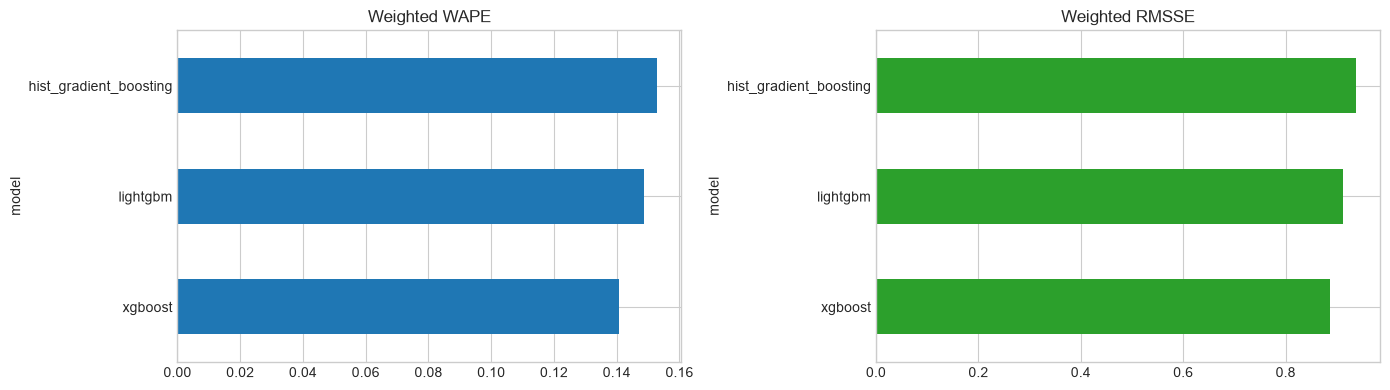

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
summary.sort_values('weighted_wape').plot(kind='barh', x='model', y='weighted_wape', ax=axes[0], legend=False)
axes[0].set_title('Weighted WAPE')
summary.sort_values('weighted_rmsse').plot(kind='barh', x='model', y='weighted_rmsse', ax=axes[1], legend=False, color='#2ca02c')
axes[1].set_title('Weighted RMSSE')
plt.tight_layout()
summary

## Results by Window

,model,cutoff,mean_mae,median_mae,weighted_mae,mean_rmse,median_rmse,weighted_rmse,mean_wape,median_wape,weighted_wape,mean_rmsse,median_rmsse,weighted_rmsse,mean_smape,median_smape,weighted_smape,series_count,actual_volume
6,xgboost,2016-01-31,98.397125,59.334934,201.345819,118.325906,75.870522,239.530218,0.276583,0.160449,0.164042,1.205544,0.943148,1.009490,23.332996,16.411533,16.891131,70,1175668.0
3,lightgbm,2016-01-31,102.237527,60.954657,205.031459,121.891707,73.920613,244.137579,0.359730,0.177207,0.170444,1.406641,0.983650,1.027005,26.569253,17.970701,17.507417,70,1175668.0
0,hist_gradient_boosting,2016-01-31,106.420653,63.512579,215.806991,127.472031,73.555221,259.703284,0.379966,0.177195,0.177418,1.466569,1.012632,1.071030,27.477142,18.115169,18.401342,70,1175668.0
7,xgboost,2016-02-28,83.756470,60.013357,154.557296,108.369240,77.025768,204.297822,0.278079,0.157667,0.139586,1.180061,0.962634,0.912242,22.529929,16.047059,13.949997,70,1176067.0
4,lightgbm,2016-02-28,88.681610,63.544470,160.509088,112.030164,76.766963,207.369924,0.372999,0.157013,0.147794,1.404654,0.977494,0.927716,26.044965,15.951332,14.619387,70,1176067.0
1,hist_gradient_boosting,2016-02-28,90.443467,63.996012,163.797511,114.428343,76.908241,212.645894,0.392997,0.161013,0.150731,1.458887,1.012286,0.946630,26.751307,16.119753,14.876914,70,1176067.0
8,xgboost,2016-03-27,71.438786,61.061666,119.107694,88.838317,72.343614,151.672087,0.261394,0.138807,0.118298,1.072548,0.839497,0.739680,20.828090,14.014265,11.492030,70,1183626.0
5,lightgbm,2016-03-27,77.155417,61.677386,124.469720,94.700855,70.754789,157.983340,0.348814,0.155152,0.127764,1.308282,0.884759,0.780954,24.366862,15.298439,12.132332,70,1183626.0
2,hist_gradient_boosting,2016-03-27,79.072466,60.879417,128.990968,96.711234,71.193570,163.420563,0.367629,0.156799,0.130938,1.356529,0.889322,0.795554,25.008035,15.482443,12.398623,70,1183626.0


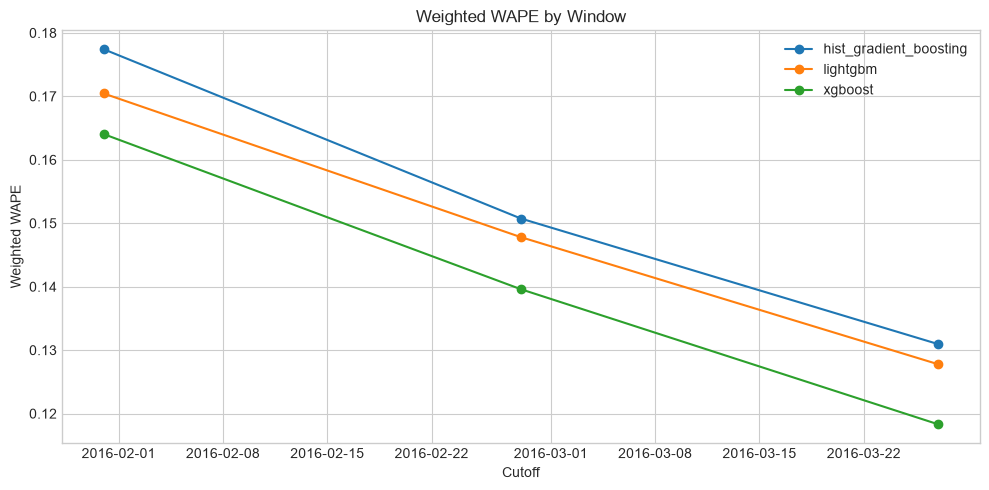

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for model, group in by_window.groupby('model'):
    ax.plot(pd.to_datetime(group['cutoff']), group['weighted_wape'], marker='o', label=model)
ax.set_title('Weighted WAPE by Window')
ax.set_xlabel('Cutoff')
ax.set_ylabel('Weighted WAPE')
ax.legend()
plt.tight_layout()
by_window.sort_values(['cutoff','weighted_wape'])

## Results by Horizon

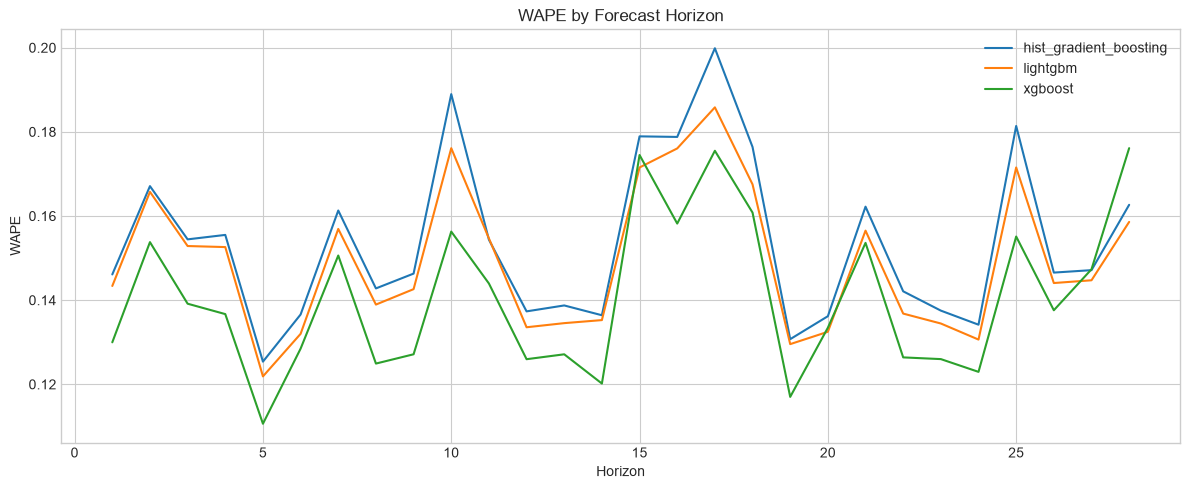

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
for model, group in by_horizon.groupby('model'):
    ax.plot(group['horizon'], group['wape'], label=model)
ax.set_title('WAPE by Forecast Horizon')
ax.set_xlabel('Horizon')
ax.set_ylabel('WAPE')
ax.legend()
plt.tight_layout()

## Representative Real vs Forecast

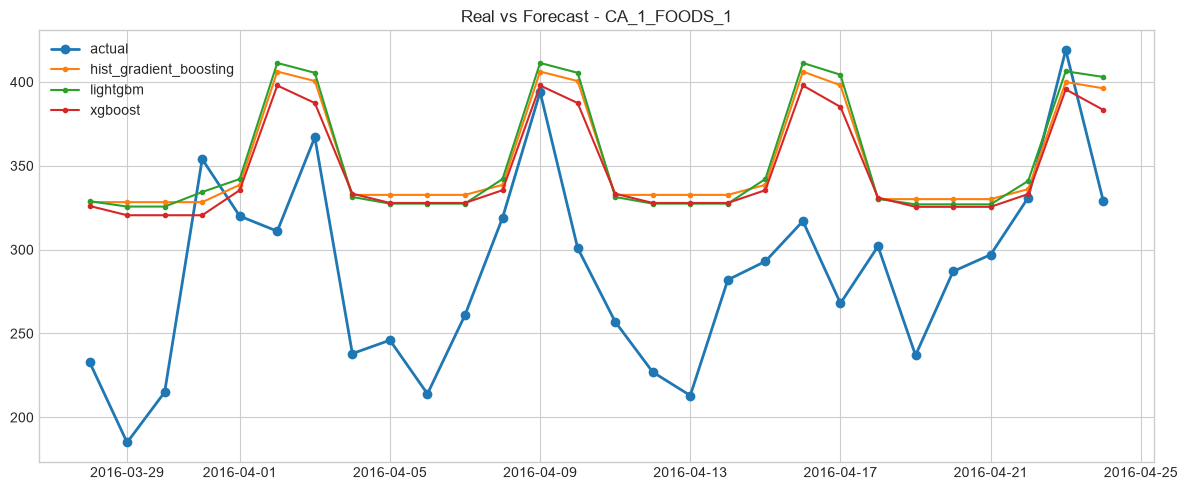

In [7]:
example_id = ml_pred['unique_id'].iloc[0]
example = ml_pred[(ml_pred['unique_id'] == example_id) & (ml_pred['window'] == 'window_3')]
fig, ax = plt.subplots(figsize=(12, 5))
actual = example[example['model'] == example['model'].iloc[0]][['forecast_date','actual']].drop_duplicates()
ax.plot(actual['forecast_date'], actual['actual'], marker='o', label='actual', linewidth=2)
for model, group in example.groupby('model'):
    ax.plot(group['forecast_date'], group['prediction'], marker='.', label=model)
ax.set_title(f'Real vs Forecast - {example_id}')
ax.legend()
plt.tight_layout()

## Series Where ML Improves or Baseline Wins

In [8]:
metrics = pd.read_parquet(PROCESSED / 'ml_metrics.parquet')
base_metrics = pd.read_parquet(PROCESSED / 'baseline_metrics.parquet')
base = base_metrics[(base_metrics['dataset']=='store_department') & (base_metrics['model']=='seasonal_naive_28')][['unique_id','cutoff','wape']].rename(columns={'wape':'baseline_wape'})
joined = metrics.merge(base, on=['unique_id','cutoff'], how='left')
joined['wape_delta'] = joined['wape'] - joined['baseline_wape']
display(joined.sort_values('wape_delta').head(10)[['model','unique_id','cutoff','wape','baseline_wape','wape_delta']])
display(joined.sort_values('wape_delta', ascending=False).head(10)[['model','unique_id','cutoff','wape','baseline_wape','wape_delta']])

,model,unique_id,cutoff,wape,baseline_wape,wape_delta
62,hist_gradient_boosting,WI_2_HOUSEHOLD_2,2016-01-31,0.136394,0.246185,-0.109791
536,xgboost,TX_3_HOBBIES_2,2016-03-27,0.256154,0.357944,-0.101790
343,xgboost,WI_3_FOODS_1,2016-02-28,0.216847,0.317933,-0.101086
202,lightgbm,WI_2_HOUSEHOLD_2,2016-01-31,0.146806,0.246185,-0.099379
411,lightgbm,WI_2_HOUSEHOLD_1,2016-02-28,0.146398,0.238256,-0.091857
271,hist_gradient_boosting,WI_2_HOUSEHOLD_1,2016-02-28,0.147715,0.238256,-0.090541
406,lightgbm,WI_2_FOODS_1,2016-02-28,0.145375,0.233949,-0.088574
132,xgboost,WI_2_HOUSEHOLD_2,2016-01-31,0.161433,0.246185,-0.084752
301,xgboost,CA_4_FOODS_1,2016-02-28,0.140148,0.224772,-0.084624
336,xgboost,WI_2_FOODS_1,2016-02-28,0.153732,0.233949,-0.080218


,model,unique_id,cutoff,wape,baseline_wape,wape_delta
445,hist_gradient_boosting,CA_4_HOBBIES_2,2016-03-27,4.684666,0.375286,4.309380
585,lightgbm,CA_4_HOBBIES_2,2016-03-27,4.387774,0.375286,4.012488
235,hist_gradient_boosting,CA_4_HOBBIES_2,2016-02-28,4.438771,0.514286,3.924485
375,lightgbm,CA_4_HOBBIES_2,2016-02-28,4.197914,0.514286,3.683629
25,hist_gradient_boosting,CA_4_HOBBIES_2,2016-01-31,3.873339,0.433134,3.440205
165,lightgbm,CA_4_HOBBIES_2,2016-01-31,3.614928,0.433134,3.181795
515,xgboost,CA_4_HOBBIES_2,2016-03-27,3.063097,0.375286,2.687811
305,xgboost,CA_4_HOBBIES_2,2016-02-28,2.801102,0.514286,2.286817
95,xgboost,CA_4_HOBBIES_2,2016-01-31,2.422103,0.433134,1.988970
242,hist_gradient_boosting,TX_1_HOBBIES_2,2016-02-28,2.070274,0.390819,1.679455


## Feature Importance

,feature,importance
0,rolling_max_28,0.257800
1,rolling_mean_28,0.168799
2,expanding_std,0.124507
3,rolling_mean_7,0.100016
4,rolling_mean_14,0.097929
5,expanding_mean,0.052838
6,rolling_max_7,0.044520
7,item_count_with_price,0.035710
8,rolling_mean_56,0.018325
9,rolling_min_7,0.016107


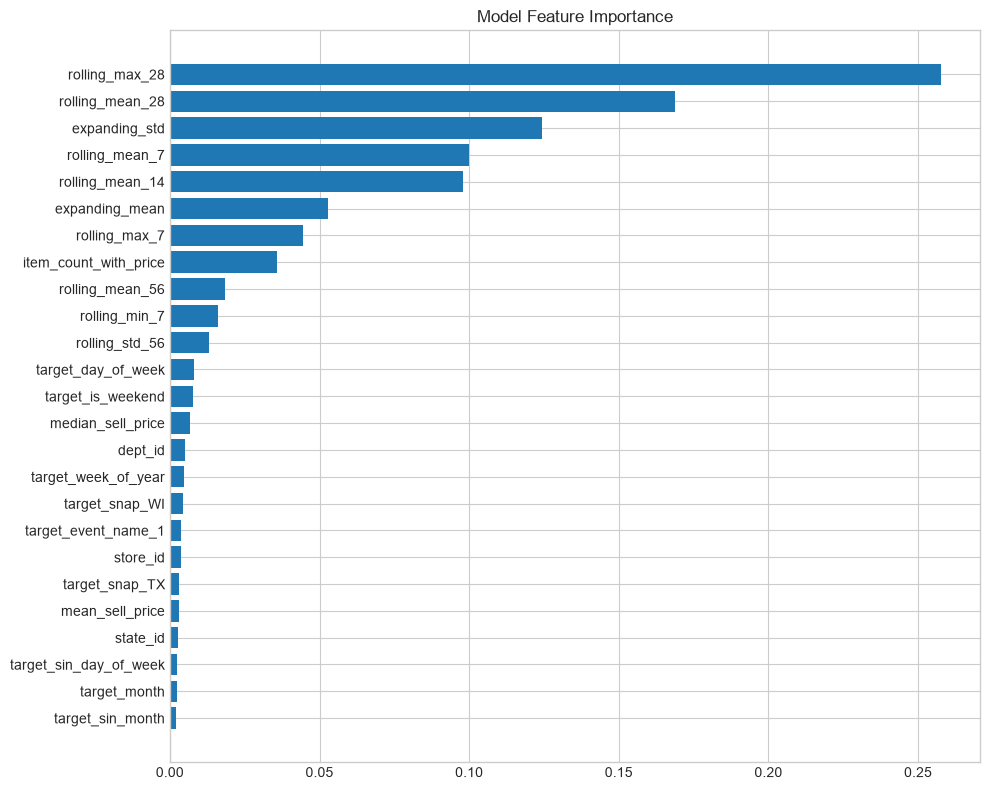

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
top = feature_importance.sort_values('importance', ascending=False).head(25).iloc[::-1]
ax.barh(top['feature'], top['importance'])
ax.set_title('Model Feature Importance')
plt.tight_layout()
feature_importance.head(20)

## Permutation Importance

In [10]:
permutation.sort_values('importance_mean', ascending=False).head(20)

,feature,importance_mean,importance_std
0,rolling_mean_28,149.952700,1.769037
1,expanding_std,77.003482,1.158756
2,rolling_max_28,55.661306,0.950476
3,expanding_mean,55.654185,1.087298
4,target_day_of_week,34.982760,1.715598
5,rolling_mean_56,32.674477,0.467564
6,rolling_mean_14,17.242091,0.365407
7,rolling_std_56,8.493858,0.166831
8,target_sin_day_of_week,6.647947,0.855542
9,rolling_mean_7,4.444290,0.198824


## Conclusions

- ML is only useful if it beats `seasonal_naive_28` across weighted WAPE, RMSSE, windows and horizons.
- The lightweight run uses 180 recent origin days per cutoff, which is a deliberate resource-control limitation.
- Feature importance is predictive, not causal.